In [ ]:


import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from transformers import pipeline

# Initialize the object detection pipeline
od_pipe = pipeline(
    task="object-detection",
    model="facebook/detr-resnet-50",
    threshold=0.1
)


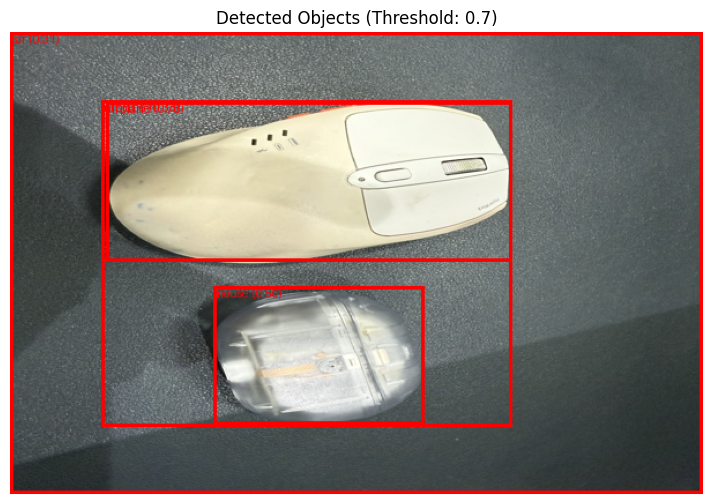

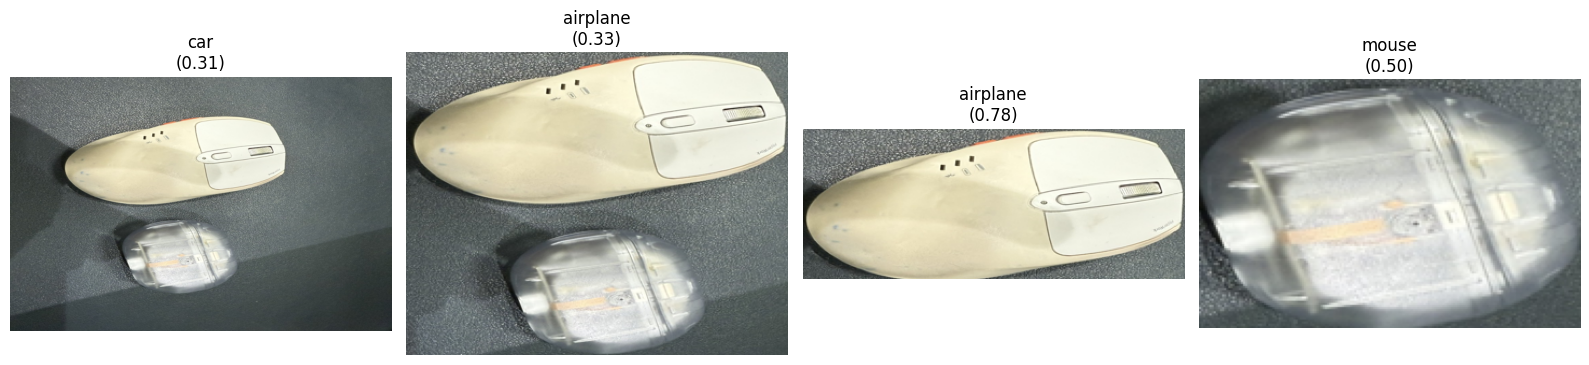

In [29]:
def load_image_from_path(image_path):
    return Image.open(image_path)


def render_results_in_image(image, results):
    draw = ImageDraw.Draw(image)
    for result in results:
        box = result['box']
        label = result['label']
        score = result['score']
        draw.rectangle([(box['xmin'], box['ymin']), (box['xmax'], box['ymax'])], outline="red", width=3)
        draw.text((box['xmin'], box['ymin']), f"{label} ({score:.2f})", fill="red")
    return image


# Load and process image
image_path = "img_test_4.jpg"
raw_image = load_image_from_path(image_path).resize((600, 400))

# Detect objects
pipeline_output = od_pipe(raw_image)

# Create figure for main image
plt.figure(figsize=(12, 6))
plt.imshow(render_results_in_image(raw_image.copy(), pipeline_output))
plt.axis('off')
plt.title('Detected Objects (Threshold: 0.7)')
plt.show()


# Crop and display detected objects
def get_cropped_objects(image, results):
    return [(
        image.crop((r['box']['xmin'], r['box']['ymin'], r['box']['xmax'], r['box']['ymax'])),
        r['label'],
        r['score']
    ) for r in results]


cropped_objects = get_cropped_objects(raw_image, pipeline_output)

# Sort cropped objects by size (width * height)
cropped_objects.sort(key=lambda x: x[0].width * x[0].height, reverse=True)

# Display cropped objects in a grid
if cropped_objects:
    cols = 4
    rows = (len(cropped_objects) + cols - 1) // cols
    plt.figure(figsize=(16, 4 * rows))

    for i, (cropped_img, label, score) in enumerate(cropped_objects, 1):
        plt.subplot(rows, cols, i)
        plt.imshow(cropped_img)
        plt.title(f"{label}\n({score:.2f})")
        plt.axis('off')

    plt.tight_layout()
    plt.show()